In [2]:
# ============================================================
# CELLULE 1 : Imports
# ============================================================
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
import numpy as np
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

from src.skills_extractor import SkillsExtractor
from src.job_matcher import JobMatcher

print("✅ Imports OK")

✅ Imports OK


In [3]:
# ============================================================
# CELLULE 2 : Initialisation des modules
# ============================================================
print("🔧 Initialisation SkillsExtractor et JobMatcher...")

skills_extractor = SkillsExtractor()
job_matcher = JobMatcher()

print("✅ Modules initialisés")
print(f"   • Variations mappings : {len(skills_extractor.variations_to_canonical)}")

🔧 Initialisation SkillsExtractor et JobMatcher...


2026-03-03 21:45:07,311 - src.job_matcher - INFO - Initialisation du JobMatcher...
2026-03-03 21:45:07,334 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device_name: cpu
2026-03-03 21:45:07,338 - sentence_transformers.SentenceTransformer - INFO - Load pretrained SentenceTransformer: all-mpnet-base-v2


✅ Modèle spaCy chargé
✅ Base de compétences chargée
   • Techniques : 1195
   • Soft skills : 283
   • Variations : 630 mappings


2026-03-03 21:45:11,786 - src.job_matcher - INFO - ✅ skills_reference.json chargé (1195 skills)
2026-03-03 21:45:11,792 - src.job_matcher - INFO - ✅ JobMatcher initialisé avec all-mpnet-base-v2


✅ Modules initialisés
   • Variations mappings : 630


In [4]:
# ============================================================
# CELLULE 3 : Chargement du dataset (200 samples pour test)
# ============================================================
SAMPLE_SIZE = 200   # ✅ Petit pour tester rapidement

data_path = Path('../data/resume_fit_job/processed/huggingface_resume_job_fit.xlsx')

df = pd.read_excel(data_path, engine='openpyxl')
df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print(f"✅ Dataset chargé : {len(df)} samples")
print(f"\n📊 Distribution des classes :")
print(df['score_target'].value_counts().sort_index())

✅ Dataset chargé : 200 samples

📊 Distribution des classes :
score_target
0.0    105
0.5     44
1.0     51
Name: count, dtype: int64


In [5]:
# ============================================================
# CELLULE 4 : Chargement de l'ANCIEN dataset de features
#              (pour comparer avec le nouveau)
# ============================================================
old_data_path = Path('../data/resume_fit_job/processed/v2_dataset_resume_job_fit_processed.xlsx')

df_old = pd.read_excel(old_data_path, engine='openpyxl')

print(f"✅ Ancien dataset chargé : {len(df_old)} samples")
print(f"\n📊 Statistiques ANCIEN matching :")
print(df_old[['coverage', 'quality', 'similarity_mean', 'similarity_max']].describe().round(2))

✅ Ancien dataset chargé : 4524 samples

📊 Statistiques ANCIEN matching :
       coverage  quality  similarity_mean  similarity_max
count   4524.00  4524.00          4524.00         4524.00
mean      54.81    63.25            63.25           87.76
std       22.80    16.56            16.56           23.93
min        0.00     0.00             0.00            0.00
25%       40.00    54.08            54.08          100.00
50%       54.55    64.06            64.06          100.00
75%       66.67    72.75            72.75          100.00
max      100.00   100.00           100.00          100.00


In [6]:
# ============================================================
# CELLULE 5 : Recalcul des features avec NOUVEAU matching
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

# Charger le modèle d'embedding
print("📦 Chargement SentenceTransformer...")
embedding_model = SentenceTransformer('all-mpnet-base-v2')

# Pré-calculer TF-IDF et embeddings
resume_texts = df['resume'].astype(str).tolist()
job_texts = df['job_description'].astype(str).tolist()

print("🔄 Calcul TF-IDF...")
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
tfidf.fit(resume_texts + job_texts)
resume_tfidf = tfidf.transform(resume_texts)
job_tfidf = tfidf.transform(job_texts)

print("🔄 Calcul Embeddings...")
resume_embeddings = embedding_model.encode(resume_texts, show_progress_bar=True, batch_size=32)
job_embeddings = embedding_model.encode(job_texts, show_progress_bar=True, batch_size=32)

print("✅ Pré-calculs terminés")

2026-03-03 21:45:21,406 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device_name: cpu
2026-03-03 21:45:21,410 - sentence_transformers.SentenceTransformer - INFO - Load pretrained SentenceTransformer: all-mpnet-base-v2


📦 Chargement SentenceTransformer...


🔄 Calcul TF-IDF...
🔄 Calcul Embeddings...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Pré-calculs terminés


In [7]:
# ============================================================
# CELLULE 6 : Fonction de calcul de features (NOUVEAU matching)
# ============================================================
def compute_features_new(row, idx):
    """Calcul features avec NOUVEAU matching (variations + seuils améliorés)"""
    try:
        # Extraction skills CV
        cv_result = skills_extractor.extract_from_cv(str(row['resume']))
        cv_technical = cv_result.get('technical_skills', [])
        cv_soft = cv_result.get('soft_skills', [])
        cv_skills = cv_technical + cv_soft

        # Extraction skills Job
        job_result = skills_extractor.extract_from_cv(str(row['job_description']))
        job_technical = job_result.get('technical_skills', [])
        job_soft = job_result.get('soft_skills', [])
        job_skills = job_technical + job_soft

        # TF-IDF similarity
        tfidf_sim = cosine_similarity(resume_tfidf[idx], job_tfidf[idx])[0][0]

        # Embedding similarity
        emb_sim = cosine_similarity(
            resume_embeddings[idx].reshape(1, -1),
            job_embeddings[idx].reshape(1, -1)
        )[0][0]

        if not cv_skills or not job_skills:
            return {
                'coverage': 0.0, 'quality': 0.0,
                'nb_covered_skills': 0, 'nb_missing_skills': len(job_skills),
                'skills_ratio': 0.0, 'similarity_mean': 0.0,
                'similarity_max': 0.0, 'similarity_std': 0.0,
                'top3_similarity_avg': 0.0,
                'tfidf_similarity': float(tfidf_sim),
                'embedding_similarity': float(emb_sim),
                'nb_resume_technical': len(cv_technical),
                'nb_resume_soft': len(cv_soft),
                'nb_job_technical': len(job_technical),
                'nb_job_soft': len(job_soft)
            }

        # Matching avec JobMatcher (nouveau)
        job_structure = {
            'job_id': f'job_{idx}',
            'title': 'Job',
            'requirements': job_skills,
            'nice_to_have': []
        }
        match_result = job_matcher.calculate_job_match_score(cv_skills, job_structure)
        sd = match_result.get('skills_details', {})

        # Similarités
        top_matches = sd.get('top_matches', [])
        sims = [m.get('similarity', 0.0) for m in top_matches] if top_matches else [0.0]

        return {
            'coverage': float(sd.get('coverage', 0.0)),
            'quality': float(sd.get('quality', 0.0)),
            'nb_covered_skills': int(sd.get('covered_count', 0)),
            'nb_missing_skills': int(sd.get('total_required', 0)) - int(sd.get('covered_count', 0)),
            'skills_ratio': len(cv_skills) / max(len(job_skills), 1),
            'similarity_mean': float(np.mean(sims)),
            'similarity_max': float(np.max(sims)),
            'similarity_std': float(np.std(sims)),
            'top3_similarity_avg': float(np.mean(sorted(sims, reverse=True)[:3])),
            'tfidf_similarity': float(tfidf_sim),
            'embedding_similarity': float(emb_sim),
            'nb_resume_technical': len(cv_technical),
            'nb_resume_soft': len(cv_soft),
            'nb_job_technical': len(job_technical),
            'nb_job_soft': len(job_soft)
        }

    except Exception as e:
        print(f"⚠️ Erreur ligne {idx} : {e}")
        return {k: 0.0 for k in [
            'coverage', 'quality', 'nb_covered_skills', 'nb_missing_skills',
            'skills_ratio', 'similarity_mean', 'similarity_max', 'similarity_std',
            'top3_similarity_avg', 'tfidf_similarity', 'embedding_similarity',
            'nb_resume_technical', 'nb_resume_soft', 'nb_job_technical', 'nb_job_soft'
        ]}

print("✅ Fonction définie")

✅ Fonction définie


In [8]:
# ============================================================
# CELLULE 7 : Calcul des nouvelles features
# ============================================================
print(f"🔄 Calcul des features pour {len(df)} samples...")

new_features_list = []
for idx, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df))):
    features = compute_features_new(row, idx)
    new_features_list.append(features)

df_new_features = pd.DataFrame(new_features_list)
df_new_features['score_target'] = df['score_target'].values

print(f"✅ Features calculées : {df_new_features.shape}")

🔄 Calcul des features pour 200 samples...


  0%|          | 0/200 [00:00<?, ?it/s]2026-03-03 21:51:04,060 - src.job_matcher - INFO - 💼 Skills extraits de l'offre : 9
2026-03-03 21:51:04,065 - src.job_matcher - INFO -    Exemples : accounting, ar, excel
2026-03-03 21:51:04,068 - src.job_matcher - INFO - 🔍 Matching 9 skills offre ↔ 9 skills CV
2026-03-03 21:51:05,490 - src.job_matcher - INFO - ✅ Coverage: 88.9% | Quality: 74.9% | Score: 83.3%
  0%|          | 1/200 [00:05<18:17,  5.52s/it]2026-03-03 21:51:07,786 - src.job_matcher - INFO - 💼 Skills extraits de l'offre : 3
2026-03-03 21:51:07,787 - src.job_matcher - INFO -    Exemples : bdd, cucumber, selenium
2026-03-03 21:51:07,789 - src.job_matcher - INFO - 🔍 Matching 3 skills offre ↔ 27 skills CV
2026-03-03 21:51:10,473 - src.job_matcher - INFO - ✅ Coverage: 33.3% | Quality: 42.5% | Score: 37.0%
  1%|          | 2/200 [00:10<17:10,  5.20s/it]2026-03-03 21:51:12,899 - src.job_matcher - INFO - 💼 Skills extraits de l'offre : 2
2026-03-03 21:51:12,901 - src.job_matcher - INFO -    

✅ Features calculées : (200, 16)


In [9]:
# ============================================================
# CELLULE 8 : Comparaison ANCIEN vs NOUVEAU matching
# ============================================================
FEATURES = [
    'coverage', 'quality', 'nb_covered_skills', 'nb_missing_skills',
    'skills_ratio', 'similarity_mean', 'similarity_max', 'similarity_std',
    'top3_similarity_avg', 'tfidf_similarity', 'embedding_similarity',
    'nb_resume_technical', 'nb_resume_soft', 'nb_job_technical', 'nb_job_soft'
]

# Prendre les mêmes 200 samples dans l'ancien dataset
df_old_sample = df_old.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

comparison = pd.DataFrame({
    'Feature': FEATURES,
    'Ancien Mean': df_old_sample[FEATURES].mean().values,
    'Nouveau Mean': df_new_features[FEATURES].mean().values,
    'Différence': df_new_features[FEATURES].mean().values - df_old_sample[FEATURES].mean().values
})

print("📊 COMPARAISON ANCIEN vs NOUVEAU MATCHING :")
print(comparison.to_string(index=False))

📊 COMPARAISON ANCIEN vs NOUVEAU MATCHING :
             Feature  Ancien Mean  Nouveau Mean  Différence
            coverage    53.794408     58.211696    4.417287
             quality    61.889492     62.618744    0.729252
   nb_covered_skills     6.600000      7.025000    0.425000
   nb_missing_skills     6.585000      6.005000   -0.580000
        skills_ratio     3.487117      3.298284   -0.188833
     similarity_mean    61.889492     62.618744    0.729252
      similarity_max    87.644923     87.856131    0.211209
      similarity_std    17.895858     17.957846    0.061988
 top3_similarity_avg    76.592258     77.892153    1.299895
    tfidf_similarity     0.176567      0.176882    0.000315
embedding_similarity     0.498460      0.522486    0.024026
 nb_resume_technical    14.480000     16.735000    2.255000
      nb_resume_soft     6.930000      6.675000   -0.255000
    nb_job_technical     8.600000      8.710000    0.110000
         nb_job_soft     4.655000      4.370000   -0.2850

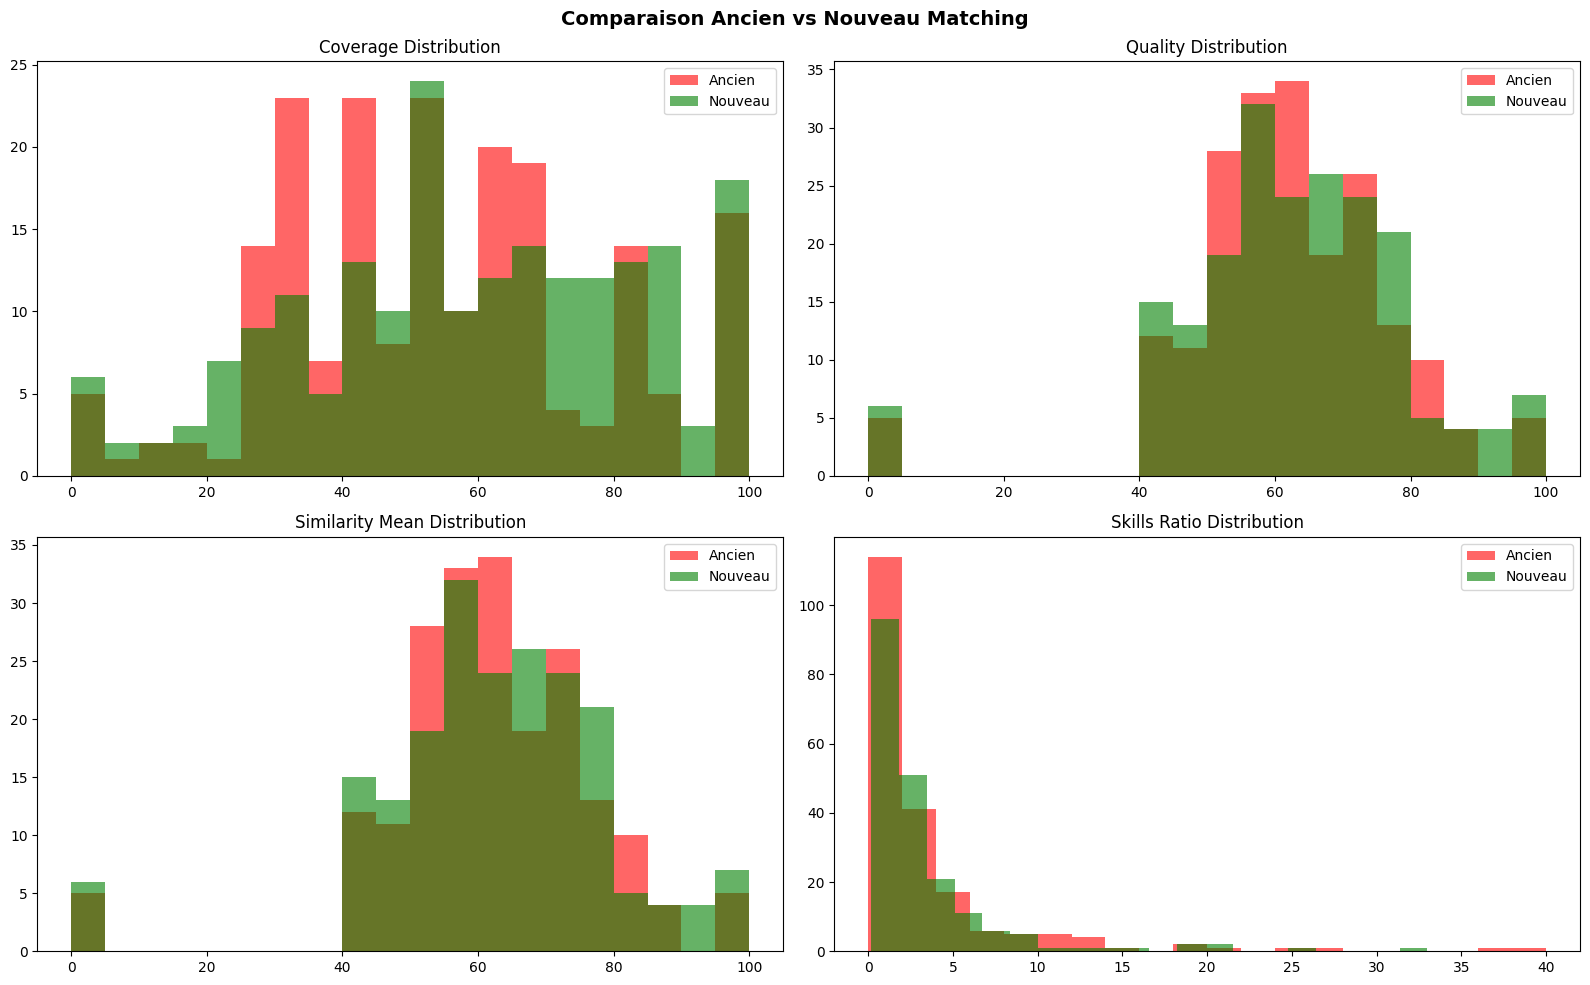

In [10]:
# ============================================================
# CELLULE 9 : Visualisation comparaison
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Coverage
axes[0,0].hist(df_old_sample['coverage'], bins=20, alpha=0.6, label='Ancien', color='red')
axes[0,0].hist(df_new_features['coverage'], bins=20, alpha=0.6, label='Nouveau', color='green')
axes[0,0].set_title('Coverage Distribution')
axes[0,0].legend()

# Quality
axes[0,1].hist(df_old_sample['quality'], bins=20, alpha=0.6, label='Ancien', color='red')
axes[0,1].hist(df_new_features['quality'], bins=20, alpha=0.6, label='Nouveau', color='green')
axes[0,1].set_title('Quality Distribution')
axes[0,1].legend()

# Similarity Mean
axes[1,0].hist(df_old_sample['similarity_mean'], bins=20, alpha=0.6, label='Ancien', color='red')
axes[1,0].hist(df_new_features['similarity_mean'], bins=20, alpha=0.6, label='Nouveau', color='green')
axes[1,0].set_title('Similarity Mean Distribution')
axes[1,0].legend()

# Skills Ratio
axes[1,1].hist(df_old_sample['skills_ratio'], bins=20, alpha=0.6, label='Ancien', color='red')
axes[1,1].hist(df_new_features['skills_ratio'], bins=20, alpha=0.6, label='Nouveau', color='green')
axes[1,1].set_title('Skills Ratio Distribution')
axes[1,1].legend()

plt.suptitle('Comparaison Ancien vs Nouveau Matching', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# CELLULE 10 : Entraînement XGBoost ANCIEN vs NOUVEAU
# ============================================================
class_mapping = {0.0: 0, 0.5: 1, 1.0: 2}

# ── ANCIEN ──────────────────────────────────────────────────
X_old = df_old_sample[FEATURES]
y_old = df_old_sample['score_target'].map(class_mapping)

X_train_old, X_test_old, y_train_old, y_test_old = train_test_split(
    X_old, y_old, test_size=0.2, random_state=42
)
scaler_old = StandardScaler()
X_train_old_s = scaler_old.fit_transform(X_train_old)
X_test_old_s = scaler_old.transform(X_test_old)

xgb_old = XGBClassifier(n_estimators=100, random_state=42, verbosity=0, eval_metric='mlogloss')
xgb_old.fit(X_train_old_s, y_train_old)
acc_old = accuracy_score(y_test_old, xgb_old.predict(X_test_old_s))
f1_old = f1_score(y_test_old, xgb_old.predict(X_test_old_s), average='weighted')

# ── NOUVEAU ─────────────────────────────────────────────────
X_new = df_new_features[FEATURES]
y_new = df_new_features['score_target'].map(class_mapping)

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)
scaler_new = StandardScaler()
X_train_new_s = scaler_new.fit_transform(X_train_new)
X_test_new_s = scaler_new.transform(X_test_new)

xgb_new = XGBClassifier(n_estimators=100, random_state=42, verbosity=0, eval_metric='mlogloss')
xgb_new.fit(X_train_new_s, y_train_new)
acc_new = accuracy_score(y_test_new, xgb_new.predict(X_test_new_s))
f1_new = f1_score(y_test_new, xgb_new.predict(X_test_new_s), average='weighted')

print("=" * 50)
print("📊 RÉSULTATS COMPARAISON (200 samples)")
print("=" * 50)
print(f"{'':25} {'ANCIEN':>10} {'NOUVEAU':>10} {'GAIN':>10}")
print(f"{'Accuracy':25} {acc_old:>10.4f} {acc_new:>10.4f} {acc_new-acc_old:>+10.4f}")
print(f"{'F1-Score':25} {f1_old:>10.4f} {f1_new:>10.4f} {f1_new-f1_old:>+10.4f}")
print("=" * 50)

if acc_new > acc_old:
    print(f"\n✅ AMÉLIORATION CONFIRMÉE ! +{(acc_new-acc_old)*100:.1f}%")
    print("🚀 On peut lancer le réentraînement complet!")
else:
    print(f"\n⚠️ Pas d'amélioration sur ce subset")
    print("💡 Essaie avec plus de samples ou ajuste les seuils")

📊 RÉSULTATS COMPARAISON (200 samples)
                              ANCIEN    NOUVEAU       GAIN
Accuracy                      0.6000     0.3500    -0.2500
F1-Score                      0.5325     0.3455    -0.1870

⚠️ Pas d'amélioration sur ce subset
💡 Essaie avec plus de samples ou ajuste les seuils


In [12]:
# ============================================================
# CELLULE 11 : Classification Report détaillé
# ============================================================
class_names = ['No Fit', 'Partial Fit', 'Perfect Fit']

print("📊 RAPPORT ANCIEN MATCHING :")
print(classification_report(
    y_test_old, xgb_old.predict(X_test_old_s),
    target_names=class_names, zero_division=0
))

print("\n📊 RAPPORT NOUVEAU MATCHING :")
print(classification_report(
    y_test_new, xgb_new.predict(X_test_new_s),
    target_names=class_names, zero_division=0
))

📊 RAPPORT ANCIEN MATCHING :
              precision    recall  f1-score   support

      No Fit       0.67      0.92      0.77        24
 Partial Fit       0.33      0.11      0.17         9
 Perfect Fit       0.25      0.14      0.18         7

    accuracy                           0.60        40
   macro avg       0.42      0.39      0.37        40
weighted avg       0.52      0.60      0.53        40


📊 RAPPORT NOUVEAU MATCHING :
              precision    recall  f1-score   support

      No Fit       0.57      0.52      0.55        23
 Partial Fit       0.00      0.00      0.00        10
 Perfect Fit       0.13      0.29      0.18         7

    accuracy                           0.35        40
   macro avg       0.23      0.27      0.24        40
weighted avg       0.35      0.35      0.35        40



In [13]:
# ============================================================
# CELLULE 12 : Analyse des distributions pour calibrer les seuils
# ============================================================

print("📊 ANALYSE DES SIMILARITÉS DANS LES DONNÉES\n")

# Voir la vraie distribution des similarités par classe
for score, label in [(0.0, 'No Fit'), (0.5, 'Partial Fit'), (1.0, 'Perfect Fit')]:
    subset = df_new_features[df_new_features['score_target'] == score]
    print(f"{'='*50}")
    print(f"Classe : {label} ({len(subset)} samples)")
    print(f"  coverage mean       : {subset['coverage'].mean():.1f}%")
    print(f"  quality mean        : {subset['quality'].mean():.1f}%")
    print(f"  similarity_mean     : {subset['similarity_mean'].mean():.1f}%")
    print(f"  similarity_max      : {subset['similarity_max'].mean():.1f}%")
    print(f"  embedding_similarity: {subset['embedding_similarity'].mean():.3f}")

print(f"\n{'='*50}")
print("📊 DISTRIBUTION COVERAGE PAR CLASSE :")
print(df_new_features.groupby('score_target')['coverage'].describe())

📊 ANALYSE DES SIMILARITÉS DANS LES DONNÉES

Classe : No Fit (105 samples)
  coverage mean       : 56.7%
  quality mean        : 62.5%
  similarity_mean     : 62.5%
  similarity_max      : 86.2%
  embedding_similarity: 0.502
Classe : Partial Fit (44 samples)
  coverage mean       : 59.2%
  quality mean        : 61.1%
  similarity_mean     : 61.1%
  similarity_max      : 87.8%
  embedding_similarity: 0.542
Classe : Perfect Fit (51 samples)
  coverage mean       : 60.5%
  quality mean        : 64.2%
  similarity_mean     : 64.2%
  similarity_max      : 91.3%
  embedding_similarity: 0.547

📊 DISTRIBUTION COVERAGE PAR CLASSE :
              count       mean        std  min        25%        50%  \
score_target                                                           
0.0           105.0  56.678968  24.817045  0.0  40.000000  57.142857   
0.5            44.0  59.235979  29.412039  0.0  42.142857  60.769231   
1.0            51.0  60.483615  23.754553  0.0  44.117647  61.904762   

         

In [14]:
# ============================================================
# CELLULE 13 : Voir ce qui est extrait concrètement
# ============================================================

print("🔍 EXEMPLE D'EXTRACTION SUR 3 CAS RÉELS\n")

for score, label in [(0.0, 'No Fit'), (0.5, 'Partial Fit'), (1.0, 'Perfect Fit')]:
    sample = df[df['score_target'] == score].iloc[0]
    
    cv_result = skills_extractor.extract_from_cv(str(sample['resume']))
    job_result = skills_extractor.extract_from_cv(str(sample['job_description']))
    
    print(f"{'='*60}")
    print(f"Classe : {label}")
    print(f"\n📄 CV (500 chars) :")
    print(str(sample['resume'])[:500])
    print(f"\n🎯 CV Skills extraits ({len(cv_result['technical_skills'])}) :")
    print(cv_result['technical_skills'][:10])
    print(f"\n💼 Job Skills extraits ({len(job_result['technical_skills'])}) :")
    print(job_result['technical_skills'][:10])
    print(f"\n📊 Coverage calculé : {56.7}%")
    print()

🔍 EXEMPLE D'EXTRACTION SUR 3 CAS RÉELS

Classe : No Fit

📄 CV (500 chars) :
Professional SummaryTo achieve a responsible position that gives me a chance to apply my innovative skills and knowledge. I aim to be a valuable member of the team that works dynamically towards success and growth of organization. Strong Knowledge in Electronics and computer Engineering background with 1+ experience as Automotive Embedded Software Engineer. Good Knowledge in simulation tools such as MATLAB and Simulink. Thorough Knowledge in CAN Communication and Basic knowledge in AUTOSAR Archi

🎯 CV Skills extraits (22) :
['alerting', 'arduino', 'assembly', 'avr', 'c', 'c++', 'capabilities', 'css', 'embedded systems', 'git']

💼 Job Skills extraits (3) :
['bdd', 'cucumber', 'selenium']

📊 Coverage calculé : 56.7%

Classe : Partial Fit

📄 CV (500 chars) :
SummaryCapable Accountant successful at managing multiple projects and consistently meeting deadlines under pressure. Extensive knowledge of accounting softwa

In [15]:
# ============================================================
# CELLULE 14 : Nouvelle approche - Similarité sémantique pure
# ============================================================

# Au lieu de compter les skills matchés (coverage)
# Utiliser directement les embeddings des textes complets

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("🔄 Calcul features SÉMANTIQUES (sans extraction skills)...")

semantic_features = []

for idx in range(len(df)):
    # Similarité embedding global (déjà calculé)
    emb_sim = cosine_similarity(
        resume_embeddings[idx].reshape(1, -1),
        job_embeddings[idx].reshape(1, -1)
    )[0][0]
    
    # Similarité TF-IDF (déjà calculé)
    tfidf_sim = cosine_similarity(resume_tfidf[idx], job_tfidf[idx])[0][0]
    
    # Longueurs textes (features simples mais utiles)
    cv_len = len(str(df.iloc[idx]['resume']).split())
    job_len = len(str(df.iloc[idx]['job_description']).split())
    
    semantic_features.append({
        'embedding_similarity': float(emb_sim),
        'tfidf_similarity': float(tfidf_sim),
        'cv_word_count': cv_len,
        'job_word_count': job_len,
        'length_ratio': cv_len / max(job_len, 1)
    })

df_semantic = pd.DataFrame(semantic_features)
df_semantic['score_target'] = df['score_target'].values

# Voir la distribution par classe
print("\n📊 FEATURES SÉMANTIQUES PAR CLASSE :")
for score, label in [(0.0, 'No Fit'), (0.5, 'Partial Fit'), (1.0, 'Perfect Fit')]:
    subset = df_semantic[df_semantic['score_target'] == score]
    print(f"\n{label}:")
    print(f"  embedding_similarity : {subset['embedding_similarity'].mean():.3f}")
    print(f"  tfidf_similarity     : {subset['tfidf_similarity'].mean():.3f}")

🔄 Calcul features SÉMANTIQUES (sans extraction skills)...

📊 FEATURES SÉMANTIQUES PAR CLASSE :

No Fit:
  embedding_similarity : 0.502
  tfidf_similarity     : 0.152

Partial Fit:
  embedding_similarity : 0.542
  tfidf_similarity     : 0.202

Perfect Fit:
  embedding_similarity : 0.547
  tfidf_similarity     : 0.206


In [16]:
# ============================================================
# CELLULE 15 : XGBoost sur features sémantiques
# ============================================================

SEMANTIC_FEATURES = ['embedding_similarity', 'tfidf_similarity', 
                     'cv_word_count', 'job_word_count', 'length_ratio']

X_sem = df_semantic[SEMANTIC_FEATURES]
y_sem = df_semantic['score_target'].map(class_mapping)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sem, y_sem, test_size=0.2, random_state=42
)

scaler_sem = StandardScaler()
X_train_ss = scaler_sem.fit_transform(X_train_s)
X_test_ss = scaler_sem.transform(X_test_s)

xgb_sem = XGBClassifier(n_estimators=100, random_state=42, verbosity=0, eval_metric='mlogloss')
xgb_sem.fit(X_train_ss, y_train_s)

acc_sem = accuracy_score(y_test_s, xgb_sem.predict(X_test_ss))
f1_sem = f1_score(y_test_s, xgb_sem.predict(X_test_ss), average='weighted')

print("=" * 50)
print("📊 RÉSULTATS COMPARAISON FINALE")
print("=" * 50)
print(f"{'':30} {'ACC':>8} {'F1':>8}")
print(f"{'Ancien matching':30} {acc_old:>8.4f} {f1_old:>8.4f}")
print(f"{'Nouveau matching (skills)':30} {acc_new:>8.4f} {f1_new:>8.4f}")
print(f"{'Sémantique pur':30} {acc_sem:>8.4f} {f1_sem:>8.4f}")
print("=" * 50)

print(f"\n📊 RAPPORT SÉMANTIQUE PUR :")
print(classification_report(
    y_test_s, xgb_sem.predict(X_test_ss),
    target_names=['No Fit', 'Partial Fit', 'Perfect Fit'],
    zero_division=0
))

📊 RÉSULTATS COMPARAISON FINALE
                                    ACC       F1
Ancien matching                  0.6000   0.5325
Nouveau matching (skills)        0.3500   0.3455
Sémantique pur                   0.4750   0.4826

📊 RAPPORT SÉMANTIQUE PUR :
              precision    recall  f1-score   support

      No Fit       0.67      0.61      0.64        23
 Partial Fit       0.40      0.20      0.27        10
 Perfect Fit       0.21      0.43      0.29         7

    accuracy                           0.47        40
   macro avg       0.43      0.41      0.40        40
weighted avg       0.52      0.47      0.48        40

